<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load your cleaned dataset
df = pd.read_csv("/Users/shelsea/Documents/GitHub/assignment-1-ShelseaMarte/final_dataset.csv")
df = df.dropna()
print(df.shape)
df.head() 

(3993, 9)


,date,spy_open,spy_high,spy_low,spy_adj_close,spy_volume,log_return,rolling_volatility_30d,umich_sentiment
0,2010-02-17,82.506799,82.611556,82.110241,82.499321,168845100,0.004727,0.180552,73.6
1,2010-02-18,82.364644,83.157761,82.334714,82.985672,193708600,0.005878,0.181347,73.6
2,2010-02-19,82.768686,83.479498,82.574146,83.157761,222684900,0.002072,0.181490,73.6
3,2010-02-22,83.464545,83.486990,82.925821,83.172737,132346900,0.000180,0.180905,73.6
4,2010-02-23,82.948252,83.202646,81.945627,82.162613,207497000,-0.012219,0.183347,73.6


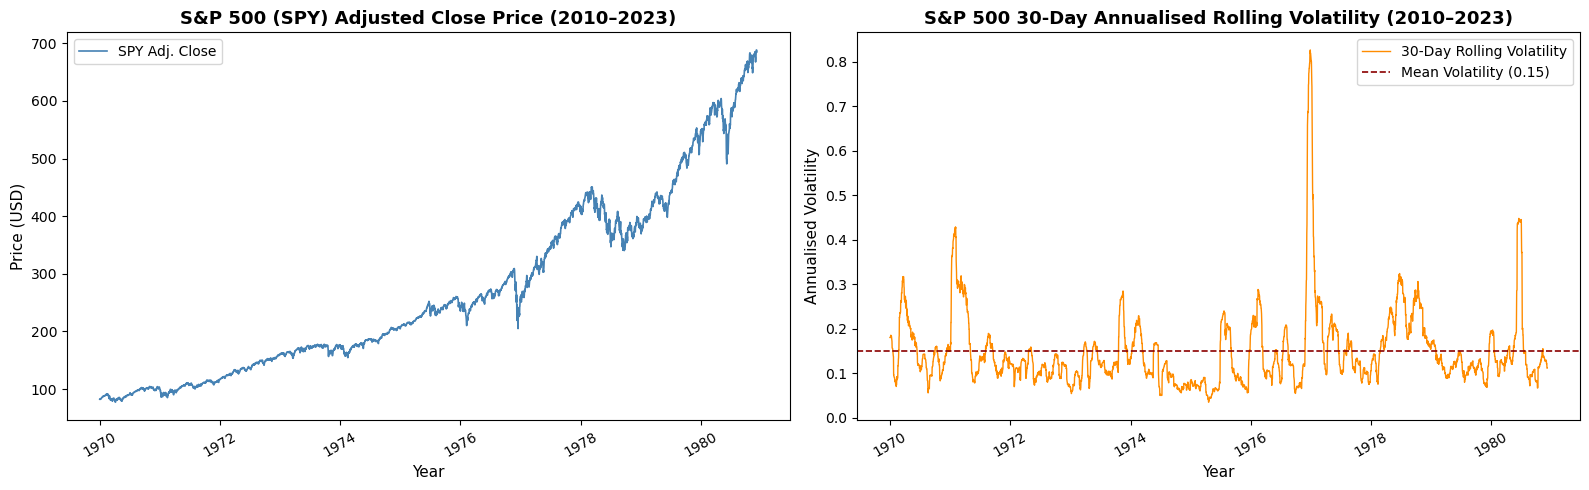

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Graph 1: SPY Adjusted Close Price over time ---
ax1.plot(df["date"], df["spy_adj_close"], color="steelblue", linewidth=1.2, label="SPY Adj. Close")
ax1.set_title("S&P 500 (SPY) Adjusted Close Price (2010–2023)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("Price (USD)", fontsize=11)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(axis="x", rotation=30)
ax1.legend(loc="upper left", fontsize=10)

# --- Graph 2: 30-Day Rolling Volatility over time ---
mean_vol = df["rolling_volatility_30d"].mean()
ax2.plot(df["date"], df["rolling_volatility_30d"], color="darkorange", linewidth=1.0, label="30-Day Rolling Volatility")
ax2.axhline(mean_vol, color="darkred", linestyle="--", linewidth=1.2, label=f"Mean Volatility ({mean_vol:.2f})")
ax2.set_title("S&P 500 30-Day Annualised Rolling Volatility (2010–2023)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Year", fontsize=11)
ax2.set_ylabel("Annualised Volatility", fontsize=11)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(axis="x", rotation=30)
ax2.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("figure1_side_by_side.png", dpi=150, bbox_inches="tight")
plt.show()

**Graph 1: SPY Adjusted Close Price:**
The S&P 500 grew steadily from $100 to $400 between 2010 and 2023,
with a sharp but brief decline in early 2020 (COVID crash) followed by a strong recovery.
This suggests that despite short-term shocks, long-run equity market performance has been strongly upward trending.

**Graph 2: 30-Day Rolling Volatility:**
Market volatility spikes dramatically during crisis periods, notably in early 2020
then quickly returns toward its historical mean.
This confirms that volatility is mean-reverting and that extreme uncertainty is typically short-lived.

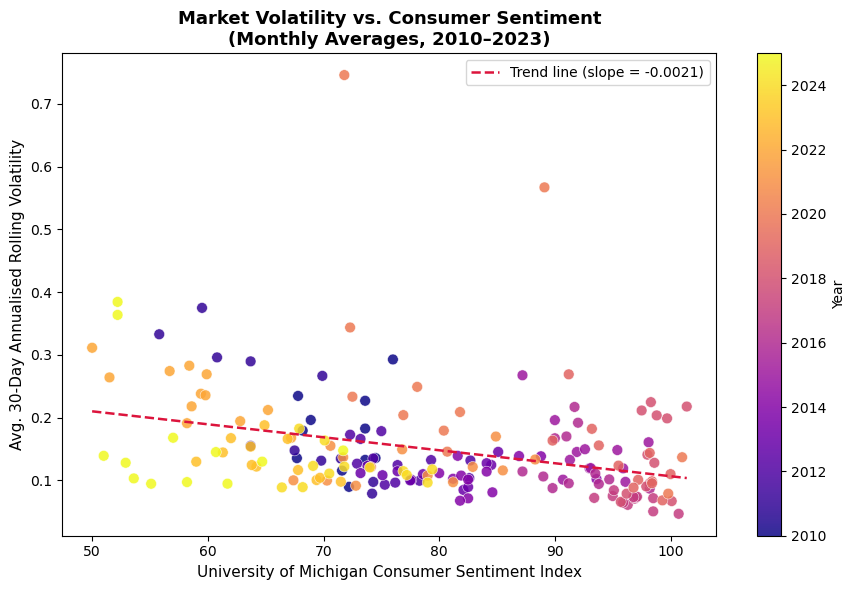

In [21]:
# Fix date column type
df["date"] = pd.to_datetime(df["date"])

# Aggregate to monthly averages for a cleaner scatter
df["year_month"] = df["date"].dt.to_period("M")
monthly = df.groupby("year_month").agg(
    avg_volatility=("rolling_volatility_30d", "mean"),
    avg_sentiment=("umich_sentiment", "mean")
).reset_index()
monthly["year"] = monthly["year_month"].dt.year

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    monthly["avg_sentiment"],
    monthly["avg_volatility"],
    c=monthly["year"],
    cmap="plasma",
    s=60,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.4
)

m, b = np.polyfit(monthly["avg_sentiment"], monthly["avg_volatility"], 1)
x_line = np.linspace(monthly["avg_sentiment"].min(), monthly["avg_sentiment"].max(), 200)
ax.plot(x_line, m * x_line + b, color="crimson", linewidth=1.8,
        linestyle="--", label=f"Trend line (slope = {m:.4f})")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Year", fontsize=10)

ax.set_title("Market Volatility vs. Consumer Sentiment\n(Monthly Averages, 2010–2023)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("University of Michigan Consumer Sentiment Index", fontsize=11)
ax.set_ylabel("Avg. 30-Day Annualised Rolling Volatility", fontsize=11)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

**Graph 3 Volatility vs. Consumer Sentiment (Scatter Plot):**
The scatter plot reveals a negative relationship between consumer sentiment and market volatility:
higher confidence tends to coincide with calmer markets, while low sentiment aligns with elevated volatility.
This supports the "wealth effect" hypothesis that when markets are turbulent, consumers feel less financially secure.
